# Projection matrix generation for SPECT with GATE 10 - Example of 3D Shepp Logan Phantom

This notebook provides a practical demonstration of **projection matrix generation for SPECT using GATE 10**.  
A 3D water based Shepp Logan Phantom is used


# General Definitions

*The notebook expects the project files to be available in PROJECT_PATH*

In [1]:
PROJECT_PATH = "./"
OUTPUT_BASE = PROJECT_PATH

In [2]:
from pathlib import Path

required_files = [
    f"{PROJECT_PATH}/GATE10.py",
]

for f in required_files:
    if not Path(f).exists():
        raise FileNotFoundError(f"Required file not found: {f}")

print("All required files found.")

All required files found.


In [3]:
!pip install --upgrade pip

In [4]:
!pip install --upgrade opengate

  Using cached opengate-10.1.0-py3-none-any.whl.metadata (5.1 kB)
INFO: pip is looking at multiple versions of opengate to determine which version is compatible with other requirements. This could take a while.
  Using cached opengate-10.0.3-py3-none-any.whl.metadata (14 kB)
  Using cached opengate-10.0.2-py3-none-any.whl.metadata (14 kB)
  Using cached opengate-10.0.1-py3-none-any.whl.metadata (14 kB)


In [5]:
!pip install pydicom opengate uproot awkward tensorflow scikit-image

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import uproot, awkward as ak
import tensorflow as tf
import time
import sys
sys.path.append(PROJECT_PATH)
from scipy.ndimage import convolve
import os
import pickle as pk
import pydicom
from tqdm import tqdm  # optional: for progress bar
from skimage.transform import radon

import GATE10

def writedata(df,fname):
    pk.dump(df,open(fname,'wb'))
    return

def readdata(fname):
    return pk.load(open(fname,'rb'))


def printProgressBar(i,max,postText):
    n_bar =40 #size of progress bar
    j= i/max
    sys.stdout.write('\r')
    sys.stdout.write(f"[{'=' * int(n_bar * j):{n_bar}s}] {int(100 * j)}%  {postText}")
    sys.stdout.flush()



def smear(image, d):
    result = np.copy(image)  # Create a copy of the input image to store the result

    # Create a kernel of ones with a size of (2*d+1) for convolution
    kernel = np.ones((2*d + 1, 2*d + 1))

    # Use convolution to compute the sum of the neighborhood for each cell
    sums = convolve(image, kernel, mode='constant', cval=0)

    # Count the number of neighbors for each cell
    num_neighbors = convolve(np.ones_like(image), kernel, mode='constant', cval=0)

    # Compute the local average by dividing the sum by the number of neighbors
    local_average = sums / num_neighbors



    # Replace each cell with its corresponding local average
    result = local_average


    return result



In [7]:
def load_dicom(file_path):
    """
    Loads a DICOM file containing emission data and returns the image as a NumPy array
    along with metadata in a dictionary.

    Args:
        file_path (str): Full path to the DICOM file.

    Returns:
        tuple: (image_array, metadata_dict)
            - image_array (np.ndarray): The image pixel data.
            - metadata_dict (dict): Dictionary of DICOM metadata.
    """
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"File '{file_path}' not found.")

    try:
        dicom_data = pydicom.dcmread(file_path)

        # Extract pixel data to numpy array
        image_array = dicom_data.pixel_array

        # Extract metadata to dictionary
        metadata_dict = {}
        for elem in dicom_data:
            if elem.VR != 'SQ':  # Skip sequences to avoid complexity
                metadata_dict[elem.keyword or elem.tag] = elem.value

        return image_array, metadata_dict

    except Exception as e:
        print(f"Error reading DICOM file: {e}")
        return None, None


# Create 3D Shepp Logan Phantom

In [8]:
ndim=nrays=128
nangle=120
phantom_width=400 #mm
PIXEL_SIZE = phantom_width/ndim
print(f'PIXEL_SIZE = {PIXEL_SIZE} mm')
scale=1

PIXEL_SIZE = 3.125 mm


In [9]:
def return_ellipsoid(a, b, c, x0, y0, z0, rot=[1,0,0]):
    # rotation angle from vector projection on XY plane
    theta = np.arctan2(rot[1], rot[0])  # angle of vector (uy, ux)
    # rotation matrix around z-axis
    ct, st = np.cos(-theta), np.sin(-theta)
    x2 =  ct * (xx - x0) - st * (yy - y0)
    y2 =  st * (xx - x0) + ct * (yy - y0)
    z2 =  zz - z0
    # ellipsoid equation
    mask = (x2/a)**2 + (y2/b)**2 + (z2/c)**2 <= 1.0
    ellipsoid = np.zeros_like(xx, dtype=np.float32)
    ellipsoid[mask] = 1.0   
    return ellipsoid

import numpy as np

def add_ellipsoid_to_world(
    world: np.ndarray,
    a: float, b: float, c: float,     # half-axes in mm
    x0: float, y0: float, z0: float,  # center in mm
    rot=(1.0, 0.0, 0.0),              # direction in XY plane (like your original)
    voxel_size_mm: float = 4.0,
    value: float = 1.0,
    normalize: bool = 1
) -> np.ndarray:
    """
    Draw a rotated ellipsoid into the 3D 'world' array (in place) and return it.

    world:
        3D array (nx, ny, nz), interpreted as world[x,y,z], centered at (0,0,0).
    a, b, c:
        Half-axes of ellipsoid in mm (before rotation).
    x0, y0, z0:
        Center of ellipsoid in mm in the same coordinate system.
    rot:
        (ux, uy, uz) giving direction projected in XY-plane.
        Matches your original rotation convention.
    voxel_size_mm:
        Size of cubic voxels in mm.
    value:
        Value to ADD where ellipsoid is present (can be μ, activity, label, etc.).
    """
    nx, ny, nz = world.shape

    # Coordinates for each axis, centered at 0
    x_coords = (np.arange(nx) - nx // 2) * voxel_size_mm
    y_coords = (np.arange(ny) - ny // 2) * voxel_size_mm
    z_coords = (np.arange(nz) - nz // 2) * voxel_size_mm

    # Match your original: meshgrid(x, y, z, indexing="ij") → [x, y, z]
    xx, yy, zz = np.meshgrid(x_coords, y_coords, z_coords, indexing="ij")

    # Shift to ellipsoid center
    Xs = xx - x0
    Ys = yy - y0
    Zs = zz - z0

    # Same rotation logic as your return_ellipsoid
    ux, uy, uz = rot
    theta = np.arctan2(uy, ux)  # angle of (ux, uy)

    ct, st = np.cos(-theta), np.sin(-theta)
    x2 =  ct * Xs - st * Ys
    y2 =  st * Xs + ct * Ys
    z2 =  Zs

    mask = (x2/a)**2 + (y2/b)**2 + (z2/c)**2 <= 1.0

    if normalize:
        world[mask] += value/mask.sum()
    else:
        world[mask] += value
    return world


In [10]:
world = np.zeros((ndim, ndim, ndim), dtype=np.float32)


# Ellipsoid half-lengths (mm)
a, b, c = 150.0, 200.0, 140.0
x0, y0, z0 = 0.0, 0.0, 0.0
dx = dy = dz = PIXEL_SIZE #4.0 # mm
x = np.arange(-a-10, a+10, dx)
y = np.arange(-b-10, b+10, dy)
z = np.arange(-c-10, c+10, dz)
xx, yy, zz = np.meshgrid(x, y, z, indexing="ij")



# source 0
world = add_ellipsoid_to_world(
    world,
    a, b, c,
    x0, y0, z0,
    rot=(1.0, 0.0, 0.0),   # major axis along +x
    voxel_size_mm=PIXEL_SIZE,
    value=3000000 ,
)

# source 1
a, b, c = 24,68,80
x0, y0, z0 = 48.0, 4.0, 0.0
a*=scale ; b*=scale ; c*=scale
x0*=scale ; y0*=scale ; z0*=scale
world= add_ellipsoid_to_world(    world,
    a, b, c,
    x0, y0, z0,
    rot=(-3.0, 1.0, 0.0),   # major axis along +x
    voxel_size_mm=PIXEL_SIZE,
    value=325000,
)

# source 2
a, b, c = 34,90,80
x0, y0, z0 = -48.0, 4.0, 0.0
a*=scale ; b*=scale ; c*=scale
x0*=scale ; y0*=scale ; z0*=scale
world = add_ellipsoid_to_world(    world,
    a, b, c,
    x0, y0, z0,
    rot=(3.0, 1.0, 0.0),   # major axis along +x
    voxel_size_mm=PIXEL_SIZE,
    value=610000,
)

# source 3
a, b, c = 46,54,80
x0, y0, z0 = 0.0, 80.0, 0.0
a*=scale ; b*=scale ; c*=scale
x0*=scale ; y0*=scale ; z0*=scale
world = add_ellipsoid_to_world(    world,
    a, b, c,
    x0, y0, z0,
    rot=(1.0, 0.0, 0.0),   # major axis along +x
    voxel_size_mm=PIXEL_SIZE,
    value=1000000.0,
)

# source 4
a, b, c = 10,10,80
x0, y0, z0 = 0.0, 26.0, 0.0
a*=scale ; b*=scale ; c*=scale
x0*=scale ; y0*=scale ; z0*=scale
world = add_ellipsoid_to_world(    world,
    a, b, c,
    x0, y0, z0,
    rot=(1.0, 0.0, 0.0),   # major axis along +x
    voxel_size_mm=PIXEL_SIZE,
    value=40000,
)

# source 5
a, b, c = 10,10,80
x0, y0, z0 = 0.0, -22.0, 0.0
a*=scale ; b*=scale ; c*=scale
x0*=scale ; y0*=scale ; z0*=scale
world = add_ellipsoid_to_world(    world,
    a, b, c,
    x0, y0, z0,
    rot=(1.0, 0.0, 0.0),   # major axis along +x
    voxel_size_mm=PIXEL_SIZE,
    value=40000,
)

# source 6
a, b, c = 10,5,80
x0, y0, z0 = -22, -128.0, 0.0
a*=scale ; b*=scale ; c*=scale
x0*=scale ; y0*=scale ; z0*=scale
world = add_ellipsoid_to_world(    world,
    a, b, c,
    x0, y0, z0,
    rot=(1.0, 0.0, 0.0),   # major axis along +x
    voxel_size_mm=PIXEL_SIZE,
    value=20000,
)

# source 7
a, b, c = 5,5,80
x0, y0, z0 = 0.0, -128.0, 0.0
a*=scale ; b*=scale ; c*=scale
x0*=scale ; y0*=scale ; z0*=scale
world = add_ellipsoid_to_world(    world,
    a, b, c,
    x0, y0, z0,
    rot=(1.0, 0.0, 0.0),   # major axis along +x
    voxel_size_mm=PIXEL_SIZE,
    value=10000,
)

# source 8
a, b, c = 5,10,80
x0, y0, z0 = 18.0, -128.0, 0.0
a*=scale ; b*=scale ; c*=scale
x0*=scale ; y0*=scale ; z0*=scale
world = add_ellipsoid_to_world(    world,
    a, b, c,
    x0, y0, z0,
    rot=(1.0, 0.0, 0.0),   # major axis along +x
    voxel_size_mm=PIXEL_SIZE,
    value=20000 ,
)

phantom=np.transpose(world, (2, 1, 0))
attenuation_map=phantom>0

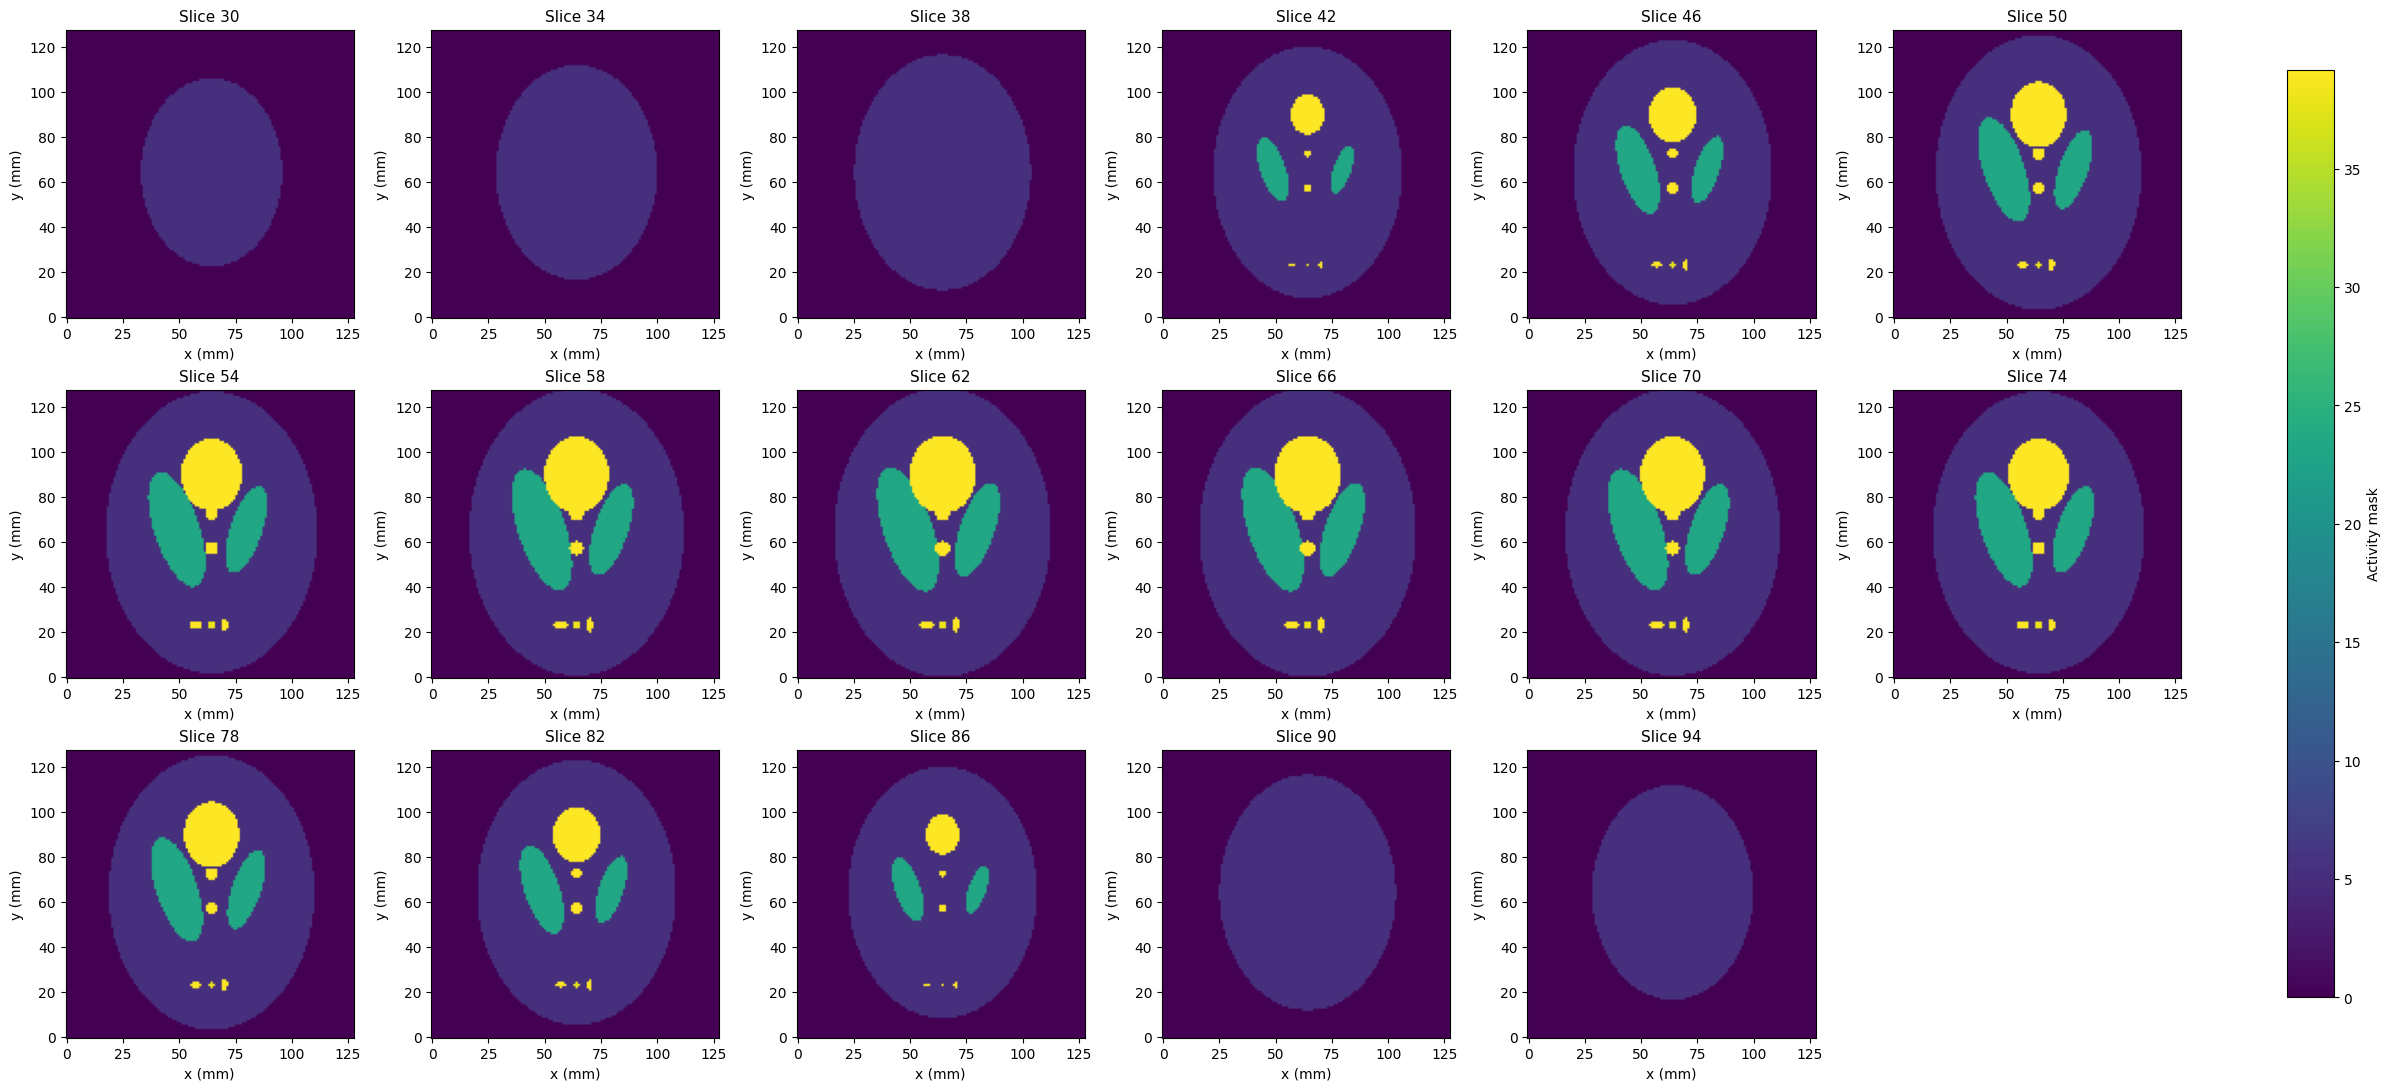

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# If source_map has shape (z, y, x)
slice_ids = list(range(30, phantom.shape[0] - 30, 4))

ncols = 6
nrows = int(np.ceil(len(slice_ids) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4*ncols, 3.6*nrows),
    constrained_layout=True
)

axes = np.atleast_1d(axes).ravel()

vmin = np.min(phantom)
vmax = np.max(phantom)/2.

im = None
for ax, k in zip(axes, slice_ids):
    im = ax.imshow(phantom[k], origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(f"Slice {k}", fontsize=11)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")

# Hide unused subplots
for ax in axes[len(slice_ids):]:
    ax.axis("off")

# Single shared colorbar for all used axes
fig.colorbar(im, ax=axes[:len(slice_ids)], label="Activity mask", shrink=0.92)

plt.show()

In [14]:
def write_mhd_raw(image: np.ndarray, out_prefix: str, spacing=(1.0, 1.0, 1.0), origin=(0.0, 0.0, 0.0)):
    """
    Save a 3D numpy array to MetaImage .mhd/.raw (float32, little-endian).
    - image: 3D array (Z, Y, X) or (Y, X) (will auto-promote to Z=1).
    - spacing: (dx, dy, dz) in mm (X, Y, Z order used in header).
    - origin:  (ox, oy, oz) in mm (X, Y, Z order used in header).
    """
    img = np.asarray(image)
    if img.ndim == 2:
        img = img[np.newaxis, ...]  # Z=1
    assert img.ndim == 3, "Image must be 2D or 3D"

    # GATE expects metaimage with Dimension = 3 and ElementSpacing = X Y Z
    # We'll store as float32, little-endian, raw.
    img = img.astype(np.float32, copy=False)

    z, y, x = img.shape
    out_prefix = Path(out_prefix)
    raw_path = out_prefix.with_suffix(".raw")
    mhd_path = out_prefix.with_suffix(".mhd")

    # Write raw binary
    img.tofile(raw_path)

    # Write header
    mhd = []
    mhd.append("ObjectType = Image")
    mhd.append("NDims = 3")
    mhd.append(f"DimSize = {x} {y} {z}")
    mhd.append("ElementType = MET_FLOAT")
    mhd.append(f"ElementSpacing = {spacing[0]} {spacing[1]} {spacing[2]}")  # X Y Z (mm)
    mhd.append(f"Position = {origin[0]} {origin[1]} {origin[2]}")           # optional, X Y Z
    mhd.append("BinaryData = True")
    mhd.append("BinaryDataByteOrderMSB = False")
    mhd.append("CompressedData = False")
    mhd.append(f"ElementDataFile = {raw_path.name}")

    mhd_path.write_text("\n".join(mhd))
    print(f"Wrote {mhd_path} and {raw_path}")



# Create (or load) Geometric Projection Matrix (pmatrix_geo)

In [15]:
write_mhd_raw(phantom,"phantom",spacing=(PIXEL_SIZE,PIXEL_SIZE,PIXEL_SIZE))

Wrote phantom.mhd and phantom.raw


In [16]:
write_mhd_raw(attenuation_map,"attenuation_map",spacing=(PIXEL_SIZE,PIXEL_SIZE,PIXEL_SIZE))

Wrote attenuation_map.mhd and attenuation_map.raw


*Only run for first time. This will generate the geometric matrix using a single cpu. This is a bit slow but it's only needed for the first time. The geometric projection matrix is saved using pk and can be loaded at a later stage.*

In [17]:
angles = np.linspace(0, 360, nangle, endpoint=False)
if not Path(PROJECT_PATH+'/pmatrix_geo.pk').exists():
  N = ndim  # image size: N x N
  pmatrix_geo = np.zeros((len(angles) * nrays, N * N))
  # --- Loop through each pixel and compute its projection ---
  for i in tqdm(range(N * N), desc="Building Radon matrix"):
      # Create image with 1 at pixel i, 0 elsewhere
      basis_img = np.zeros((N, N))
      row, col = divmod(i, N)
      basis_img[row, col] = 1.0

      # Compute projection (sinogram)
      sinogram_temp = radon(basis_img, theta=angles, circle=True)

      # Flatten the sinogram and store as column i
      pmatrix_geo[:, i] = sinogram_temp.T.flatten()

  print(f"Projection matrix shape: {pmatrix_geo.shape}")  # should be (num_angles*num_det_bins, N*N)
  pmatrix_geo=pmatrix_geo/pmatrix_geo.max()
  writedata(pmatrix_geo,PROJECT_PATH+'/pmatrix_geo.pk')
else:
  print('Loading pre-existing geometric projection matrix')
  pmatrix_geo=readdata(PROJECT_PATH+'/pmatrix_geo.pk')

Loading pre-existing geometric projection matrix


In [18]:
pmatrix_geo.shape

(15360, 16384)

# Run GATE10 using gamma photons emitted from phantom with attenuation and scatter according to mu_map.

For each simulated angle, `GATE10.py` creates an output folder named

`output_<angle>`

inside `output_base`.

This folder contains the main GATE simulation outputs for that projection angle, including:

- **projection images** in `.mhd/.raw` format, generated separately for each detector head and for the selected energy window,
- **ROOT files** containing the digitizer outputs (hits, singles, and energy-window collections),
- **a statistics file** (`stats_dual.txt`) summarizing the simulation.

In the present configuration, the most important outputs are the projection images:

- `projection_h1_... .mhd`
- `projection_h2_... .mhd`

which correspond to the simulated projections recorded by the two detector heads.

These projection files are then used in the notebook to construct the GATE-based projection matrix.


Only angles smaller than **180°** are simulated because this is a **dual-head** setup. Each simulation angle produces two projections from detector heads placed **180° apart**, so the range **0°–180°** already covers the full acquisition. Simulating angles beyond **180°** would simply duplicate views already provided by the opposite head.

This will run one projection angle at a time (total of 120 for the examples used) It's a good idea to run this using multiple independent runs.


Main arguments:

- **`angle=a`**: projection angle of the dual-head camera system around the object.
- **`isotope="I123"`**: radionuclide used in the simulation; this determines the emitted gamma-ray spectrum and the corresponding energy windows.
- **`usecollimator=False`**: runs the simulation without a collimator. This is useful here for demonstration and for faster estimation of the system response.
- **`visualize=False`**: disables interactive visualisation during the simulation.
- **`PIXEL_SIZE=PIXEL_SIZE`**: voxel size of the input maps, used also to define the detector projection pixel size.
- **`ndim=ndim`**: number of detector pixels per image dimension, so the simulated projections are of size `ndim × ndim`.
- **`dtheta=0.0`**: angular spread of the emitted photons around the nominal detector direction. Here `0.0` means a single nominal projection direction is used.
- **`nthreads=1`**: number of CPU threads used by the simulation.
- **`activity=0.01`**: source activity in MBq assigned to each of the two voxel sources. A very low value is used here for demonstration in order to keep runtimes manageable.
- **`mu_map_path=.../attenuation_map.mhd`**: path to the voxelized attenuation map used to define the phantom materials in GATE.
- **`source_map_path=.../phantom.mhd`**: path to the voxelized source distribution used to define where activity is present.
- **`output_base=projectpath`**: directory where the output files for each angle are written.


In [19]:
print(os.cpu_count())

14


## Generate sinograms

This is where the introduced activity must be realistic

In [ ]:
import subprocess
import sys
import time
from pathlib import Path

angles_to_run = [a for a in angles if a < 180.0]
max_workers = 12

running = []
remaining = list(angles_to_run)

while remaining or running:
    # start new jobs until the worker limit is reached
    while remaining and len(running) < max_workers:
        a = remaining.pop(0)

        outdir = Path(PROJECT_PATH) / f"output_{a}"
        outdir.mkdir(parents=True, exist_ok=True)

        logfile = open(outdir / "run.log", "w")

        cmd = [
            sys.executable,
            "-c",
            (
                "import sys; "
                f"sys.path.append(r'{PROJECT_PATH}'); "
                "import GATE10; "
                f"GATE10.run(angle={float(a)}, "
                "isotope='I123', "
                "usecollimator=False, "
                "visualize=False, "
                f"PIXEL_SIZE={PIXEL_SIZE}, "
                f"ndim={ndim}, "
                "dtheta=0.0, "
                "nthreads=1, "
                "activity=1, "
                f"mu_map_path=r'{PROJECT_PATH}/attenuation_map.mhd', "
                f"source_map_path=r'{PROJECT_PATH}/phantom.mhd', "
                f"output_base=r'{PROJECT_PATH}/phantom_data')"
            )
        ]

        print(f"Starting angle {a}")
        p = subprocess.Popen(cmd, stdout=logfile, stderr=logfile)
        running.append((a, p, logfile))

    # check running jobs
    still_running = []
    for a, p, logfile in running:
        ret = p.poll()
        if ret is None:
            still_running.append((a, p, logfile))
        else:
            logfile.close()
            print(f"Angle {a} finished with return code {ret}")
    running = still_running

    # avoid hammering the CPU with constant polling
    time.sleep(1)

print("All runs completed.")

In [ ]:
isotope = "I123"
analysisdirs=[PROJECT_PATH+"phantom_data"]
outname=PROJECT_PATH+'/sinograms_ideal_NC.pk'
dirs = [d for d in os.listdir(analysisdirs[0]) if d.startswith(
    "output_")]
angles = sorted(
    [float(d.split("_")[1]) for d in dirs]
)
print(angles)
print(len(angles))
def writedata(df,fname):
    pk.dump(df,open(fname,'wb'))
    return



# isotope = "I123"
# x="/nvme/scratch/cy15tl1/PERSPECT/GATE10/SL/"
# analysisdirs = [ x+"realistic"+str(i) for i in range(1,123) ]
# ndim = 128
# sinoname="sinogram_no_collimator.pk"

# dirs = [d for d in os.listdir(analysisdirs[0]) if d.startswith("output_")]
# angles = sorted([float(d.split("_")[1]) for d in dirs])

# print(angles)
# print(len(angles))

# def writedata(df, fname):
#     with open(fname, "wb") as f:
#         pk.dump(df, f)

sinograms = np.zeros((2 * len(angles), ndim, ndim), dtype=np.float32)
icount = 0

phantom_width = ndim * PIXEL_SIZE
x_edges = np.linspace(-phantom_width / 2, phantom_width / 2, ndim + 1)
z_edges = np.linspace(-phantom_width / 2, phantom_width / 2, ndim + 1)

for angle in angles:
    print("processing angle", angle)

    for analysisdir in analysisdirs:
    
        outdir = analysisdir + f"/output_{angle}/"
        
        # --- Head 1 ROOT ---
        f_h1 = uproot.open(outdir + f"{isotope}_h1.root")
        tree1 = f_h1["Hits_h1;1"]
        arr1 = tree1.arrays(library="ak")
    
        pid1 = ak.to_numpy(arr1["ParentID"])
        m1 = (pid1 == 0)
    
        hx1 = ak.to_numpy(arr1["PostPosition_X"])[m1]
        hy1 = ak.to_numpy(arr1["PostPosition_Y"])[m1]
        hz1 = ak.to_numpy(arr1["PostPosition_Z"])[m1]
    
        theta = np.deg2rad(float(angle))
        ct, st = np.cos(theta), np.sin(theta)
    
        hx1_rot = ct * hx1 + st * hy1
        # hy1_rot not needed for sinogram
    
        # --- Head 2 ROOT ---
        f_h2 = uproot.open(outdir + f"{isotope}_h2.root")
        tree2 = f_h2["Hits_h2;1"]
        arr2 = tree2.arrays(library="ak")
    
        pid2 = ak.to_numpy(arr2["ParentID"])
        m2 = (pid2 == 0)
    
        hx2 = ak.to_numpy(arr2["PostPosition_X"])[m2]
        hy2 = ak.to_numpy(arr2["PostPosition_Y"])[m2]
        hz2 = ak.to_numpy(arr2["PostPosition_Z"])[m2]
    
        theta = np.deg2rad(float(angle) + 180.0)
        ct, st = np.cos(theta), np.sin(theta)
    
        hx2_rot = ct * hx2 + st * hy2
    
        # ================== sinogram =========================
        # (z_det, x_det) using your chosen edges
        sino1, _, _ = np.histogram2d(hz1, hx1_rot, bins=(z_edges, x_edges))
        sino2, _, _ = np.histogram2d(hz2, hx2_rot, bins=(z_edges, x_edges))
    
        sinograms[icount, :, :] += sino2
        sinograms[icount + len(angles), :, :] += sino1

    icount += 1

writedata(sinograms,outname)
print("Saved: ",outname)


In [20]:
sinograms=readdata('sinograms_ideal_NC.pk')

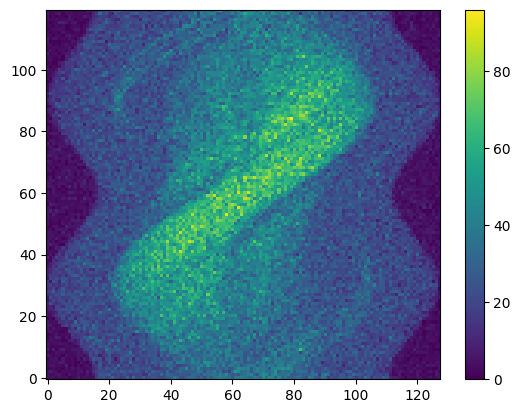

In [21]:
plt.imshow(sinograms[:,64,:],origin='lower')
plt.colorbar()

## Generate projections from GATE output (if not done)

In this case the source is the phantom volume and is unformly generated. The actual source actividies are unknown



In [ ]:
import subprocess
import sys
import time
from pathlib import Path

angles_to_run = [a for a in angles if a < 180.0]
max_workers = 12

running = []
remaining = list(angles_to_run)

while remaining or running:
    # start new jobs until the worker limit is reached
    while remaining and len(running) < max_workers:
        a = remaining.pop(0)

        outdir = Path(PROJECT_PATH) / f"output_{a}"
        outdir.mkdir(parents=True, exist_ok=True)

        logfile = open(outdir / "run.log", "w")

        cmd = [
            sys.executable,
            "-c",
            (
                "import sys; "
                f"sys.path.append(r'{PROJECT_PATH}'); "
                "import GATE10; "
                f"GATE10.run(angle={float(a)}, "
                "isotope='I123', "
                "usecollimator=False, "
                "visualize=False, "
                f"PIXEL_SIZE={PIXEL_SIZE}, "
                f"ndim={ndim}, "
                "dtheta=0.0, "
                "nthreads=1, "
                "activity=3, "
                f"mu_map_path=r'{PROJECT_PATH}/attenuation_map.mhd', "
                f"source_map_path=r'{PROJECT_PATH}/attenuation_map.mhd', "
                f"output_base=r'{PROJECT_PATH}/projection_data')"
            )
        ]

        print(f"Starting angle {a}")
        p = subprocess.Popen(cmd, stdout=logfile, stderr=logfile)
        running.append((a, p, logfile))

    # check running jobs
    still_running = []
    for a, p, logfile in running:
        ret = p.poll()
        if ret is None:
            still_running.append((a, p, logfile))
        else:
            logfile.close()
            print(f"Angle {a} finished with return code {ret}")
    running = still_running

    # avoid hammering the CPU with constant polling
    time.sleep(1)

print("All runs completed.")

In [ ]:

isotope = "I123"
analysisdirs=[PROJECT_PATH+"projection_data"]

outname=PROJECT_PATH+'/projections_ideal_NC.pk'

dirs = [d for d in os.listdir(analysisdirs[0]) if d.startswith(
    "output_")]

angles = sorted(
    [float(d.split("_")[1]) for d in dirs]
)

print(angles)
print(len(angles))


def writedata(df,fname):
    pk.dump(df,open(fname,'wb'))
    return



projections = np.zeros((2*len(angles), ndim, ndim, ndim), dtype=np.float32)
icount = 0
for angle in angles:
    print('processing angle ',angle)
    for analysisdir in analysisdirs:

        outdir = analysisdir+f"/output_{angle}/"
        f_h1 = uproot.open(outdir + f"{isotope}_h1.root")
        tree1 = f_h1["Hits_h1;1"]
        arr1 = tree1.arrays(library="ak")
        pid1 = ak.to_numpy(arr1["ParentID"])
        m1 = (pid1 == 0)
        ex1 = ak.to_numpy(arr1["TrackVertexPosition_X"])
        ex1=ex1[m1]
        ey1 = ak.to_numpy(arr1["TrackVertexPosition_Y"])
        ey1=ey1[m1]
        ez1 = ak.to_numpy(arr1["TrackVertexPosition_Z"])
        ez1=ez1[m1]


        # --- Head 2 ROOT ---
        f_h2 = uproot.open(outdir + f"{isotope}_h2.root")
        tree2 = f_h2["Hits_h2;1"]
        arr2 = tree2.arrays(library="ak")
        pid2 = ak.to_numpy(arr2["ParentID"])
        m2 = (pid2 == 0)
        ex2 = ak.to_numpy(arr2["TrackVertexPosition_X"])
        ex2=ex2[m2]
        ey2 = ak.to_numpy(arr2["TrackVertexPosition_Y"])
        ey2=ey2[m2]
        ez2 = ak.to_numpy(arr2["TrackVertexPosition_Z"])
        ez2=ez2[m2]

        phantom_width = ndim * PIXEL_SIZE
        x_edges = np.linspace(-phantom_width/2, phantom_width/2,  ndim + 1)
        y_edges = np.linspace(-phantom_width/2, phantom_width/2, ndim + 1)
        z_edges = np.linspace(-phantom_width/2, phantom_width/2, ndim + 1)
        # ================== projection matrix =========================
        samples_front = np.vstack([ez1, ey1, ex1]).T  # (N,3) as (z, x, y)
        projection1, _ = np.histogramdd(
            samples_front,
            bins=(z_edges, y_edges, x_edges)
        )
        samples_rear = np.vstack([ez2, ey2, ex2]).T
        projection2, _ = np.histogramdd(
            samples_rear,
            bins=(z_edges, y_edges, x_edges)
        )
        projections[icount,             :, :, :] += projection2  # h2
        projections[icount+len(angles), :, :, :] += projection1  # h1

        icount += 1
#    break
projections=projections[::-1]

writedata(projections,outname)


In [ ]:
projections.shape

In [22]:
projections=readdata("projections_ideal_NC.pk")

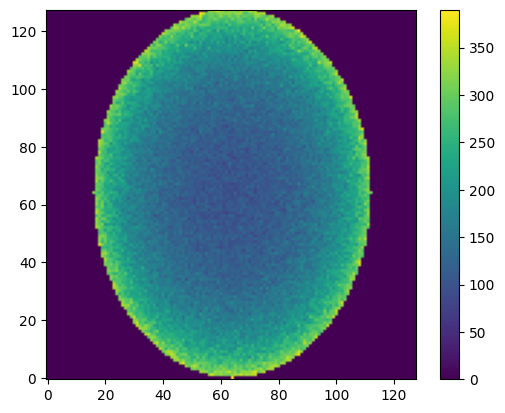

In [23]:
plt.imshow(projections[:,64,:,:].sum(axis=0),origin='lower')
plt.colorbar()

# Application to a specific section

## Create 2D projection matrix

## Projection-matrix model used here

Two projection-matrix models are considered:

- **Geometric matrix (`pmatrix_geo`)**: constructed from a simplified geometric forward model.
- **GATE-based corrected matrix**: obtained by combining the geometric model with Monte Carlo-derived corrections based on attenuation and acquisition physics.

This allows a direct comparison between a simplified system model and a more realistic Monte Carlo-informed model.

In [ ]:
projections=readdata('./projections_ideal_NC.pk')

In [24]:
nslice=64

In [25]:
pmatrix_gate_NC=np.zeros((nangle,nrays,ndim,ndim))
for iang in range(nangle):
    for iray in range(nrays):
        pmatrix_gate_NC[iang,iray,:,:]=(pmatrix_geo.reshape(nangle,nrays,ndim,ndim))[iang,iray,:,:]*\
        projections[iang,nslice,:,:] #.sum(axis=0)
#pmatrix_gate_datscan_WC=pmatrix_gate_datscan_WC/pmatrix_gate_datscan_WC.max()


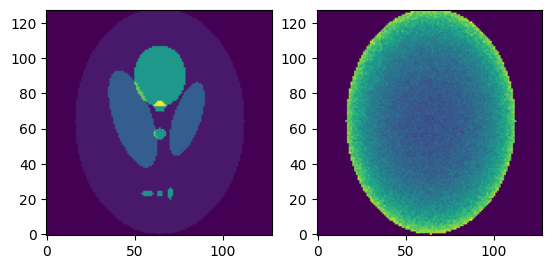

In [26]:
plt.subplot(1,2,1)
plt.imshow(phantom[nslice],origin='lower')
plt.subplot(1,2,2)
plt.imshow(projections.sum(axis=0)[nslice,:,:],origin='lower')

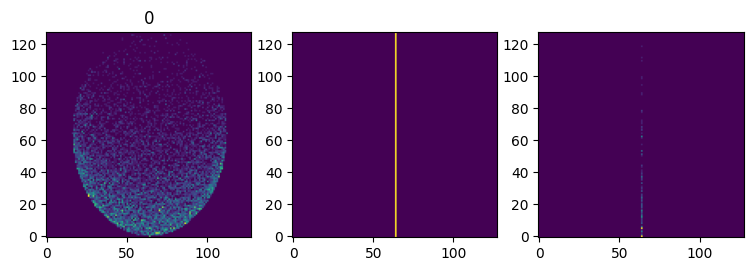

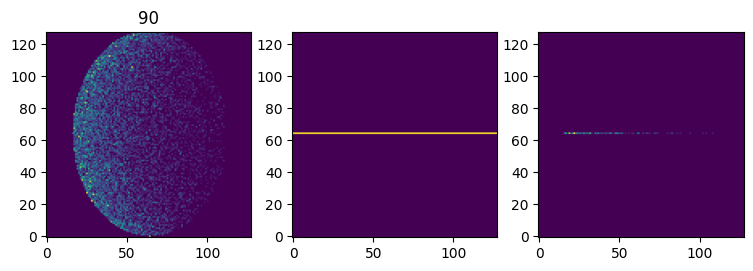

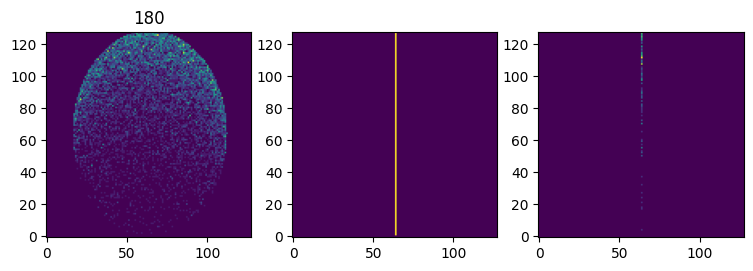

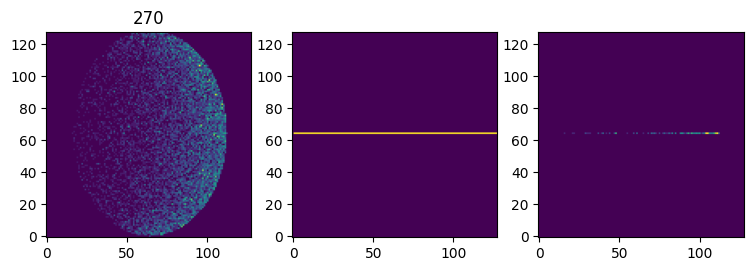

In [27]:
for i in range(nangle):
    if i % 30 ==0:
        plt.figure(figsize=(9,4))
        plt.subplot(1,3,1)
        plt.imshow(projections[i,nslice,:,:],origin='lower')
        plt.title(str(i*3))
        plt.subplot(1,3,2)
        plt.imshow(pmatrix_geo.reshape(nangle,nrays,ndim,ndim)[i,64,:,:],origin='lower')
        plt.subplot(1,3,3)
        plt.imshow(pmatrix_gate_NC[i,64,:,:],origin='lower')
        plt.show()
#plt.imshow(projection2)

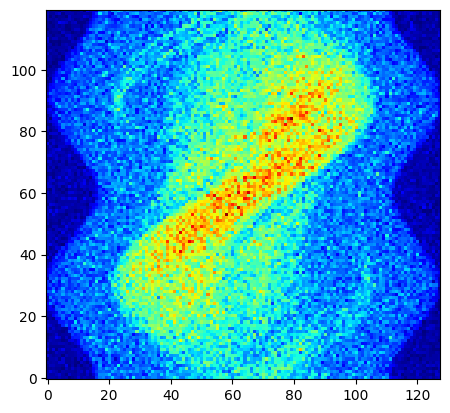

In [28]:
sinogram=sinograms[:120,nslice,:]
plt.imshow(sinogram,origin='lower',cmap='jet')

## Define MLEM and load to gpu

In [29]:

def normimg(img):
    return img/np.nanmean(img)
def printProgressBar(i,max,postText):
    n_bar =40 #size of progress bar
    j= i/max
    sys.stdout.write('\r')
    sys.stdout.write(f"[{'=' * int(n_bar * j):{n_bar}s}] {int(100 * j)}%  {postText}")
    sys.stdout.flush()

def mlem_reconstruction(
    PM,
    sinogram_gpu,
    ndim,
    n_iter=10,
    epsilon=1e-10,
    kernel_params=[],
    *,
    # Optional physical constraints / safeguards
    enforce_positivity=True,          # activity must be >= 0
    mask_outside_fov=True,            # voxels with zero sensitivity forced to 0
    use_proper_sensitivity=True,      # replaces (projection_sum + 1) with max(projection_sum, eps)
    preserve_total_counts=False,       # renormalize image each iter to match total measured counts
    count_relax=0.2
):
    # Sensitivity (a.k.a. normalization image): s = P^T 1
    projection_sum = tf.reduce_sum(PM, axis=0)  # shape: (ndim*ndim,)

    # Optional FOV mask: voxels that are never "seen" by the system matrix
    if mask_outside_fov:
        fov_mask = tf.cast(projection_sum > 0.0, tf.float32)  # 1 where observable
    else:
        fov_mask = tf.ones_like(projection_sum, dtype=tf.float32)

    # Safer denominator: do NOT bias with +1; only protect division by zero
    if use_proper_sensitivity:
        denom = tf.maximum(projection_sum, tf.constant(epsilon, tf.float32))
    else:
        # Keeps your original behavior (not recommended physically)
        denom = projection_sum + 1.0

    def gaussian_kernel(size, sigma):
        ax = np.linspace(-(size // 2), size // 2, size)
        xx, yy = np.meshgrid(ax, ax)
        kernel = np.exp(-0.5 * (xx**2 + yy**2) / sigma**2)
        kernel /= np.sum(kernel)
        return kernel

    if len(kernel_params) > 0:
        kernel = gaussian_kernel(kernel_params[0], kernel_params[1])

    # Initial image (positive)
    reconstructed_image = tf.Variable(np.ones(ndim * ndim), dtype=tf.float32)

    # Apply FOV mask at init if enabled
    if mask_outside_fov:
        reconstructed_image.assign(reconstructed_image * fov_mask)

    start_time = time.time()
    chi2_loss = -1.0

    # For optional global renormalization (heuristic; only enable if you want it)
    y_sum = tf.reduce_sum(tf.cast(sinogram_gpu, tf.float32))

    for iter in range(n_iter):
        printProgressBar(iter, n_iter, '' + str(chi2_loss))

        # Optional smoothing (heuristic regularization)
        if len(kernel_params) > 0:
            rimage = reconstructed_image.numpy()
            temp = convolve(np.reshape(rimage, (ndim, ndim)), kernel, mode='reflect').ravel()
            reconstructed_image.assign(temp)

        # Physical constraint: non-negativity
        if enforce_positivity:
            reconstructed_image.assign(tf.maximum(reconstructed_image, 0.0))

        # Physical constraint: zero outside FOV (voxels with zero sensitivity)
        if mask_outside_fov:
            reconstructed_image.assign(reconstructed_image * fov_mask)

        # Forward projection
        forward_projection = tf.linalg.matvec(PM, reconstructed_image)
        forward_projection = tf.maximum(forward_projection, tf.constant(epsilon, tf.float32))

        # Compute ratio
        ratio = sinogram_gpu / forward_projection

        # Back-projection
        back_projection = tf.linalg.matvec(tf.transpose(PM), ratio)

        # MLEM update with correct/safe denominator
        reconstructed_image.assign(reconstructed_image * (back_projection / denom))

        # Optional global renormalization to match total measured counts
        # (heuristic; can be useful if your PM is not strictly probability-normalized)
        if preserve_total_counts:
            fp_sum = tf.reduce_sum(tf.linalg.matvec(PM, reconstructed_image))
            fp_sum = tf.maximum(fp_sum, tf.constant(epsilon, tf.float32))
            alpha = y_sum / fp_sum
            # softened update: alpha**count_relax
            reconstructed_image.assign(reconstructed_image * tf.pow(alpha, count_relax))
        # Monitor (your chi2-like metric)
        chi2_loss = tf.reduce_mean((forward_projection - sinogram_gpu) ** 2 / (sinogram_gpu + epsilon))

    # Final loss
    forward_projection_final = tf.linalg.matvec(PM, reconstructed_image)
    chi2_loss = tf.reduce_mean((forward_projection_final - sinogram_gpu) ** 2 / (sinogram_gpu + epsilon))

    reconstructed_image = tf.reshape(reconstructed_image, (ndim, ndim))
    cpu_time = time.time() - start_time

    print()
    print('final chi2_loss =', chi2_loss.numpy())
    return reconstructed_image, chi2_loss, cpu_time




In [30]:
pmatrix_geo.shape

(15360, 16384)

In [31]:
pmatrix_geo_gpu = tf.constant(pmatrix_geo, dtype=tf.float32)

In [32]:
pmatrix_gate_NC=pmatrix_gate_NC.reshape(nangle*nrays,ndim**2)
pmatrix_gate_NC=pmatrix_gate_NC/pmatrix_gate_NC.max()

In [33]:
pmatrix_gate_NC_gpu=tf.constant(pmatrix_gate_NC,dtype=tf.float32)

In [34]:
sinogram_gpu = tf.constant(sinogram.ravel(), dtype=tf.float32)

## Reconstruction without correction

In [35]:
reconstructed_image0_MLEM,error,t = mlem_reconstruction(pmatrix_geo_gpu,sinogram_gpu,ndim,n_iter=100,epsilon=0.0001,kernel_params=[])
print('time=',t)

[======================================= ] 99%  tf.Tensor(569.9746, shape=(), dtype=float32))
final chi2_loss = 568.6186
time= 3.8281590938568115


Text(0.5, 1.0, 'Reconstructed image')

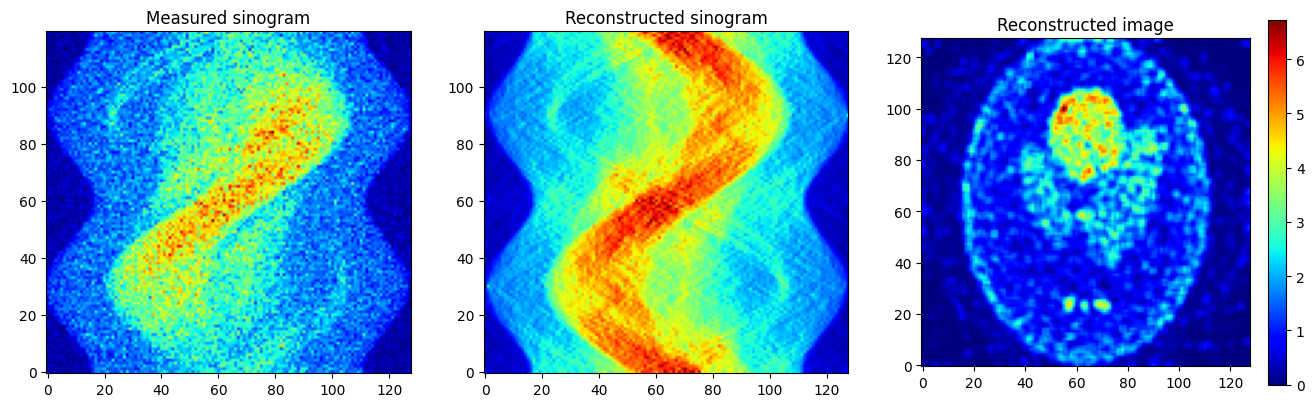

In [36]:
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
vmax=200
plt.imshow(sinogram,cmap='jet',origin='lower') #,vmax=vmax)
plt.title('Measured sinogram')
plt.subplot(1,3,2)
rsinogram0=np.dot(pmatrix_geo.reshape(nrays*nangle,ndim*ndim),(reconstructed_image0_MLEM.numpy()).ravel())
r=rsinogram0.mean()
plt.title('Reconstructed sinogram')
#print(r)
plt.imshow(rsinogram0.reshape(nangle,nrays),cmap='jet',origin='lower') #,vmax=vmax)
plt.subplot(1,3,3)
plt.imshow(smear(normimg(reconstructed_image0_MLEM),1),cmap='jet',origin='lower')
plt.colorbar(fraction=0.05)
plt.title('Reconstructed image')

## Reconstruction with GATE correction

In [37]:
reconstructed_image1_MLEM,error,t = mlem_reconstruction(pmatrix_gate_NC_gpu,sinogram_gpu,ndim,n_iter=100,epsilon=0.0001,kernel_params=[])
print('time=',t)

[======================================= ] 99%  tf.Tensor(82.072914, shape=(), dtype=float32))
final chi2_loss = 81.89657
time= 3.669973134994507


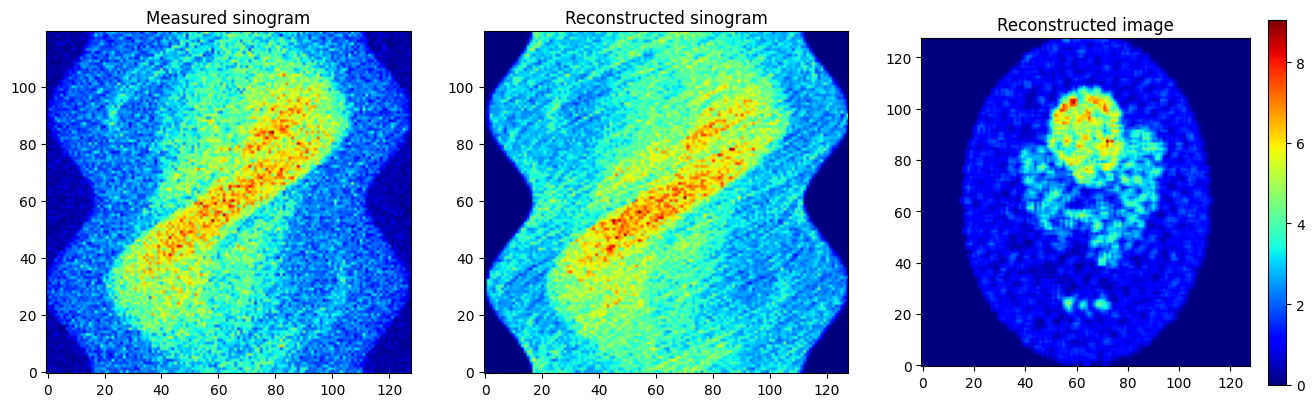

In [38]:
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
vmax=200
plt.imshow(sinogram,cmap='jet',origin='lower') #,vmax=vmax)
plt.title('Measured sinogram')
plt.subplot(1,3,2)
rsinogram1=np.dot(pmatrix_gate_NC.reshape(nrays*nangle,ndim*ndim),(reconstructed_image0_MLEM.numpy()).ravel())
r=rsinogram1.mean()
plt.title('Reconstructed sinogram')
#print(r)
plt.imshow(rsinogram1.reshape(nangle,nrays),cmap='jet',origin='lower') #,vmax=vmax)
plt.subplot(1,3,3)
plt.imshow(smear(normimg(reconstructed_image1_MLEM),1),cmap='jet',origin='lower')
plt.title('Reconstructed image')
plt.colorbar(fraction=0.05)